In [8]:
# 温位エマグラム
#    2021/11/26 R. Kurora
#    2021/11/27 R. Kurora 等混合比曲線と飽和温位プロファイル追加
#
from datetime import datetime
#
from matplotlib.collections import LineCollection
#
import metpy
import matplotlib.pyplot as plt
from metpy.plots import SkewT
from metpy.units import pandas_dataframe_to_unit_arrays, units
import metpy.calc as mpcalc
#
import numpy as np
from siphon.simplewebservice.wyoming import WyomingUpperAir

In [9]:
## 読み込む高層ゾンデ観測の指定
# 観測日時
dt = datetime(2021, 11, 19, 12)

# 地点番号
# stNo = [47401,47412,47418,47582,47600,47646,47678,47741,47778,47807,47827,
#     47909,47918,47945,47971,47991,89532];
station = '47401'

In [10]:
## 時刻と地点番号から高層データを読み込む
df = WyomingUpperAir.request_data(dt, station)

# 単位付きの辞書型データへ変換
data = pandas_dataframe_to_unit_arrays(df)

# 便宜上、データ種別の別名作成
p = data['pressure']
T = data['temperature']
Td = data['dewpoint']
u = data['u_wind']
v = data['v_wind']
h = data['height']

In [11]:
## 温位、飽和温位、相当温位、飽和相当温位の算出
pt = mpcalc.potential_temperature(p,T)
spt = mpcalc.potential_temperature(p,Td)
ept = mpcalc.equivalent_potential_temperature(p,T,Td)
sept = mpcalc.saturation_equivalent_potential_temperature(p,T)

In [12]:
## 温位エマグラムの補助線として、横軸を温位とした等飽和混合比曲線を作成
# metpy.plots.SkewTのクラスに追加する
def plot_mixing_lines_pt(self, mixing_ratio=None, pressure=None, **kwargs):
        r"""Plot lines of constant mixing ratio for Potential Temperature Emagram.

        Adds lines of constant mixing ratio (isohumes) to the
        plot. The default style of these lines is dashed green lines with an
        alpha value of 0.8. These can be overridden using keyword arguments.

        Parameters
        ----------
        mixing_ratio : array_like, optional
            Unitless mixing ratio values to plot. If none are given, default
            values are used.
        pressure : array_like, optional
            Pressure values to be included in the isohumes. If not
            specified, they will be linearly distributed across the current
            plotted pressure range up to 600 mb.
        kwargs
            Other keyword arguments to pass to :class:`matplotlib.collections.LineCollection`

        Returns
        -------
        matplotlib.collections.LineCollection
            instance created

        See Also
        --------
        :class:`matplotlib.collections.LineCollection`

        """
        # Remove old lines
        if self.mixing_lines:
            self.mixing_lines.remove()

        # Default mixing level values if necessary
        if mixing_ratio is None:
            mixing_ratio = np.array([0.0004, 0.001, 0.002, 0.004, 0.007, 0.01,
                                     0.016, 0.024, 0.032]).reshape(-1, 1)

        # Set pressure range if necessary
        if pressure is None:
            pressure = units.Quantity(np.linspace(600, max(self.ax.get_ylim())), 'mbar')

        # Assemble data for plotting
        td = mpcalc.dewpoint(mpcalc.vapor_pressure(pressure, mixing_ratio))
        pt = mpcalc.potential_temperature(pressure,td)
        # 単位を変換しないと
        pt = pt.to(units.degree_Celsius)
        linedata = [np.vstack((t.m, pressure.m)).T for t in pt]

        # Add to plot
        kwargs.setdefault('colors', 'g')
        kwargs.setdefault('linestyles', 'dashed')
        kwargs.setdefault('alpha', 0.8)
        self.mixing_lines = self.ax.add_collection(LineCollection(linedata, **kwargs))
        return self.mixing_lines
#
## メソッドを追加
metpy.plots.SkewT.plot_mixing_lines_pt = plot_mixing_lines_pt

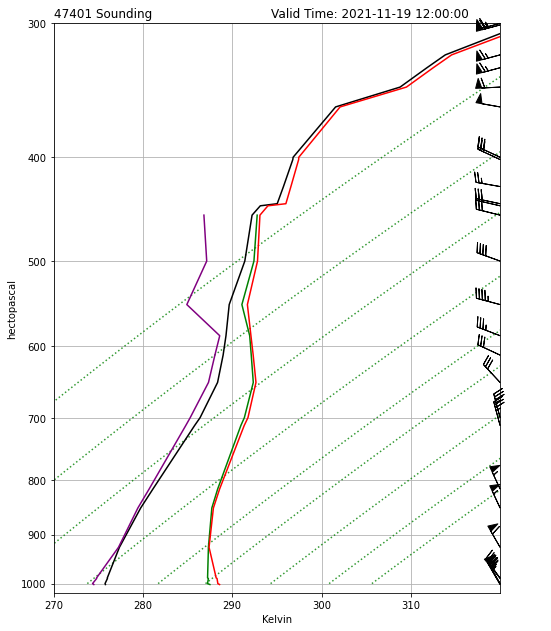

In [14]:
## 作図設定
# 図のサイズ指定
fig_size=(8, 16)

# 描画範囲
AxTmax = 320    # Kelvin
AxTmin = 270
AxPtop = 300    # hPa
AxPBot = 1020

# 目盛の表示指定
# XLabel = [270,280,290,300,310,320,330] * units.K 
XLabel = np.arange(AxTmin, AxTmax, 10) * units.K
AxTmax = AxTmax * units.K
AxTmin = AxTmin * units.K 

## 作図
fig = plt.figure(figsize=fig_size)

# Initiate the skew-T plot type from MetPy class loaded earlier
# asplectを大きくすると、縦長となる
skew = SkewT(fig, rotation=0, aspect=120)

# 軸の設定
skew.ax.set_xlim(AxTmin, AxTmax)
skew.ax.set_ylim(AxPBot, AxPtop)

# X軸の目盛表示 (これがないと自動でCelsius単位で表示される)
skew.ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, pos: "%d"%(273.15 + x)))
skew.ax.set_xticks(XLabel)
skew.ax.set_xlabel('Kelvin')

# 等飽和混合比曲線(横軸:相当温位)
#   表示する混合比の指定
mr = np.array([0.0004, 0.001, 0.002, 0.004, 0.007, 0.01,0.016, 0.024, 0.032]).reshape(-1, 1)
# 700hPa面より上にも線を引くために指定する
mix_p = np.arange(1000, 99, -20) * units.hPa
skew.plot_mixing_lines_pt(pressure=mix_p, mixing_ratio=mr, linestyle='dotted', color='tab:blue')

# 温位、飽和温位、相当温位、飽和相当温位のプロファイル描画
skew.plot(p, pt, 'black')
skew.plot(p, ept, 'g')
skew.plot(p, sept, 'r')
skew.plot(p, spt, 'purple')

# 風の描画
#skew.plot_barbs(p[::3], u[::3], v[::3], y_clip_radius=0.03)   # 間引きを行う場合 表示数が1/3になる
skew.plot_barbs(p, u, v, y_clip_radius=0.03)

# Add some descriptive titles
plt.title('{} Sounding'.format(station), loc='left')
plt.title('Valid Time: {}        '.format(dt), loc='right');